In [1]:
!pip install pandas numpy scikit-learn vaderSentiment

In [2]:
import pandas as pd

# EDA

Nowe recenzje mają zbyt mały wpływ na pozycję oferty w wyszukiwarce. Chcemy zbudować model `P(Y=1|X)` - prawdopodobieństwo, że obejrzana oferta zostanie zarezerwowana w ciągu 24 h - i uwzględniać go przy pozycjonowaniu ofert.

Chcemy sprawdzić czy jest to wykonalne dla otrzymanych danych:

- Jak dużo informacji zawierają `sessions`, `reviews`, `listings`? Co stracimy po usunięciu braków?

- Co da się wyciągnąć z treści komentarzy (analiza sentymentu VADER) ?

## Wczytanie surowych danych


In [3]:
reviews_df = pd.read_csv("../data/raw/reviews.csv")
sessions_df = pd.read_csv("../data/raw/sessions.csv")
listings_df = pd.read_csv("../data/raw/listings.csv")

In [4]:
reviews_df.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,5.068454e+06,NaN,NaN,NaN,Ethan,NaN
1,1.892001e+07,1.125276e+18,2024-04-01,NaN,Martin,A great location for our first visit to Copenh...
2,1.309641e+07,1.666708e+08,2017-07-04,32939959.0,NaN,Rune was awesome! The place was in a good loca...
3,7.344462e+17,8.151277e+17,2023-01-29,18789303.0,James,Line was great for checking in and checking ou...
4,NaN,1.115075e+18,2024-03-18,562500349.0,Jules,"Cozy studio at 20 min from the city center, co..."


In [5]:
sessions_df.head()

,action,user_id,timestamp,listing_id,booking_date,booking_duration,booking_id
0,browse_listings,22786874.0,2020-03-26T09:10:44.742016,NaN,NaN,NaN,NaN
1,view_listing,22786874.0,2020-03-26T09:46:03.742016,40780623.0,NaN,NaN,NaN
2,view_listing,NaN,NaN,5068454.0,NaN,NaN,NaN
3,book_listing,22786874.0,2020-03-26T09:46:03.742016,NaN,2020-08-15,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
listings_df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,9.294375e+17,https://www.nocarz.pl/rooms/929437466908063114,2.025093e+13,2025-09-30,previous scrape,Spacious Nørrebro apartment,"Spacious, colourful and family-friendly Maison...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,2263296.0,...,NaN,5.00,NaN,NaN,f,NaN,NaN,NaN,0.0,0.18
1,1.470415e+18,https://www.nocarz.pl/rooms/1470415126062480123,2.025093e+13,2025-09-30,previous scrape,Centralt beliggende og hyggelig.,You'll have a great time here. Centrally locat...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,708758407.0,...,5.00,5.00,NaN,NaN,f,1.0,1.0,0.0,0.0,1.50
2,9.347605e+17,https://www.nocarz.pl/rooms/934760500908785664,2.025093e+13,NaN,city scrape,Cozy & central home in trendy area,My apartment includes a bedroom with a queensi...,"The location is one of the best in Copenhagen,...",https://a0.muscache.com/pictures/hosting/Hosti...,1645772.0,...,4.94,4.94,4.88,NaN,f,1.0,1.0,0.0,0.0,0.60
3,5.980420e+05,https://www.nocarz.pl/rooms/598042,2.025093e+13,2025-09-29,city scrape,NaN,"Nice flat on the top floor in Vesterbro, Copen...",Vesterbro is a fairly young area with a sea of...,https://a0.muscache.com/pictures/1dca74d3-7334...,2242384.0,...,4.90,4.95,4.70,NaN,NaN,1.0,1.0,0.0,0.0,NaN
4,NaN,https://www.nocarz.pl/rooms/1389150402776230880,NaN,NaN,city scrape,Bold 3-Room Apartment in Valby,"Enjoy a stylish stay in this cozy home, conven...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,371936500.0,...,4.50,4.63,4.50,NaN,NaN,2.0,1.0,1.0,0.0,NaN


## Podgląd tabeli


In [ ]:
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 91660 entries, 0 to 91659
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   listing_id     73429 non-null  float64
 1   id             73227 non-null  float64
 2   date           73275 non-null  str    
 3   reviewer_id    73216 non-null  float64
 4   reviewer_name  73431 non-null  str    
 5   comments       73160 non-null  str    
dtypes: float64(3), str(3)
memory usage: 4.2 MB


In [8]:
reviews_df.describe(include="all")

,listing_id,id,date,reviewer_id,reviewer_name,comments
count,7.342900e+04,7.322700e+04,73275,7.321600e+04,73431,73160
unique,NaN,NaN,4217,NaN,17097,72364
top,NaN,NaN,2025-08-31,NaN,Anna,.
freq,NaN,NaN,234,NaN,476,89
mean,3.485372e+17,8.059348e+17,NaN,1.670079e+08,NaN,NaN
std,4.850847e+17,5.527307e+17,NaN,1.765854e+08,NaN,NaN
min,2.350000e+04,5.910800e+04,NaN,4.520000e+02,NaN,NaN
25%,1.384305e+07,6.128673e+08,NaN,2.914014e+07,NaN,NaN
50%,3.900050e+07,9.454967e+17,NaN,9.389412e+07,NaN,NaN
75%,8.093455e+17,1.256446e+18,NaN,2.523785e+08,NaN,NaN


In [9]:
sessions_df.describe(include="all")

,action,user_id,timestamp,listing_id,booking_date,booking_duration,booking_id
count,992194,9.922920e+05,991468,9.192390e+05,73466,73351,76184
unique,4,NaN,862151,NaN,4571,4550,73782
top,view_listing,NaN,2023-07-14T01:11:22.364672,NaN,2024-05-22,2025-04-30,9c3c96c1-6857-4746-884c-845343431854
freq,842390,NaN,3,NaN,77,80,2
mean,NaN,1.675754e+08,NaN,6.442887e+17,NaN,NaN,NaN
std,NaN,1.770833e+08,NaN,5.723778e+17,NaN,NaN,NaN
min,NaN,4.520000e+02,NaN,2.350000e+04,NaN,NaN,NaN
25%,NaN,2.913214e+07,NaN,3.247928e+07,NaN,NaN,NaN
50%,NaN,9.430837e+07,NaN,7.180179e+17,NaN,NaN,NaN
75%,NaN,2.533066e+08,NaN,1.169477e+18,NaN,NaN,NaN


In [10]:
sessions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1240104 entries, 0 to 1240103
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   action            992194 non-null  str    
 1   user_id           992292 non-null  float64
 2   timestamp         991468 non-null  str    
 3   listing_id        919239 non-null  float64
 4   booking_date      73466 non-null   str    
 5   booking_duration  73351 non-null   str    
 6   booking_id        76184 non-null   str    
dtypes: float64(2), str(5)
memory usage: 66.2 MB


In [11]:
print(listings_df.columns.to_list())

['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availabil

In [12]:
listings_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4598 entries, 0 to 4597
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            3646 non-null   float64
 1   listing_url                                   3683 non-null   str    
 2   scrape_id                                     3657 non-null   float64
 3   last_scraped                                  3709 non-null   str    
 4   source                                        3697 non-null   str    
 5   name                                          3698 non-null   str    
 6   description                                   3612 non-null   str    
 7   neighborhood_overview                         1258 non-null   str    
 8   picture_url                                   3665 non-null   str    
 9   host_id                                       3667 non-null   float64
 10 

## Konwersja typów

`price` przychodzi jako string `"$1,098.00"`, `bathrooms_text` jako `"1 bath"`. Daty i ID też wymagają rzutowania.


In [13]:
listings_df['id'] = listings_df['id'].astype('Int64')
listings_df["accommodates"] = listings_df["accommodates"].astype("Int64")
listings_df["bedrooms"] = listings_df["bedrooms"].astype("Int64")

# Parse price: "$1,098.00" → 1098.0
listings_df['price'] = (
    listings_df['price']
    .str.replace(r'[$,]', '', regex=True)
    .astype(float)
)

# Parse bathrooms_text: "1 bath" → 1.0, keep as 'bathrooms'
listings_df['bathrooms'] = (
    listings_df['bathrooms_text']
    .str.extract(r'(\d+\.?\d*)')
    .astype(float)
)

In [14]:
reviews_df["listing_id"] = reviews_df["listing_id"].astype("Int64")
reviews_df['date'] = pd.to_datetime(reviews_df['date'])
reviews_df.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,5068454,NaN,NaT,NaN,Ethan,NaN
1,18920012,1.125276e+18,2024-04-01,NaN,Martin,A great location for our first visit to Copenh...
2,13096414,1.666708e+08,2017-07-04,32939959.0,NaN,Rune was awesome! The place was in a good loca...
3,734446232908975360,8.151277e+17,2023-01-29,18789303.0,James,Line was great for checking in and checking ou...
4,<NA>,1.115075e+18,2024-03-18,562500349.0,Jules,"Cozy studio at 20 min from the city center, co..."


In [15]:
sessions_df["user_id"] = sessions_df["user_id"].astype("Int64")
sessions_df["listing_id"] = sessions_df["listing_id"].astype("Int64")
sessions_df['timestamp'] = pd.to_datetime(sessions_df['timestamp'])
sessions_df.head()

,action,user_id,timestamp,listing_id,booking_date,booking_duration,booking_id
0,browse_listings,22786874,2020-03-26 09:10:44.742016,<NA>,NaN,NaN,NaN
1,view_listing,22786874,2020-03-26 09:46:03.742016,40780623,NaN,NaN,NaN
2,view_listing,<NA>,NaT,5068454,NaN,NaN,NaN
3,book_listing,22786874,2020-03-26 09:46:03.742016,<NA>,2020-08-15,NaN,NaN
4,NaN,<NA>,NaT,<NA>,NaN,NaN,NaN


## Wybór kolumn

Z `Listings` zostawiamy podstawowe cechy oferty: typ, pokój, liczba osób, łazienki, sypialnie, cena i dzielnica.

Rzadkie `property_type` grupujemy do `"Other"`, żeby nie tworzyć bardzo rzadkich kategorii.


In [ ]:
sessions_df = sessions_df[["action", "user_id", "timestamp", "listing_id"]]
reviews_df = reviews_df[["listing_id", "date", "comments"]]

listing_df = listings_df[['id', 'property_type', 'room_type', 'accommodates',
                          'bathrooms', 'bedrooms', 'price', 'neighbourhood_cleansed']]
listing_df = listing_df.rename(columns={'id': 'listing_id'})

# Group rare property types into "Other" (keep types with >= 30 listings)
freq = listing_df['property_type'].value_counts()
rare_types = freq[freq < 30].index
listing_df['property_type'] = listing_df['property_type'].where(
    ~listing_df['property_type'].isin(rare_types), other='Other'
)

print(f"Listings after cleanup: {len(listing_df)}")
print(f"property_type categories: {listing_df['property_type'].nunique()}")
print(listing_df['property_type'].value_counts())

Listings after cleanup: 4598
property_type categories: 8
property_type
Entire rental unit             2145
Entire condo                    958
Private room in rental unit     170
Entire home                     167
Other                           116
Entire townhouse                 65
Private room in condo            60
Entire villa                     33
Name: count, dtype: int64


## Rozkłady kluczowych atrybutów

Sprawdzamy rozkłady akcji, sesji, recenzji i podstawowych cech ofert. Najważniejsze jest pokrycie między tabelami: jeśli oferta występuje w sesji, ale nie ma jej w `Listings`, nie zbudujemy dla niej pełnego wektora cech.


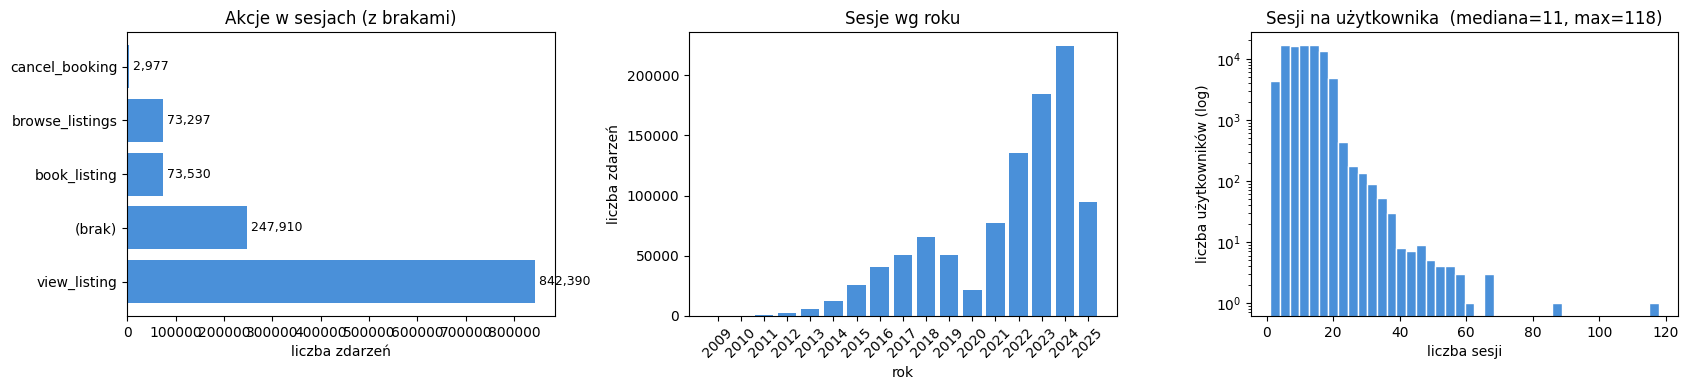

Sesji łącznie: 1,240,104
Unikalnych użytkowników: 90,113
Unikalnych ofert w sesjach: 17,322
Zakres dat: 2009-09-13 – 2025-09-08


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

act_counts = sessions_df['action'].fillna('(brak)').value_counts()
ax = axes[0]
labels = [str(x) for x in act_counts.index]
ax.barh(labels, act_counts.values, color='#4a90d9')
ax.set_title('Akcje w sesjach (z brakami)')
ax.set_xlabel('liczba zdarzeń')
for i, v in enumerate(act_counts.values):
    ax.text(v, i, f' {v:,}', va='center', fontsize=9)

sess_time = sessions_df.dropna(subset=['timestamp']).copy()
sess_time['year'] = sess_time['timestamp'].dt.year.astype(int)
year_counts = sess_time['year'].value_counts().sort_index()
ax = axes[1]
ax.bar([str(y) for y in year_counts.index], year_counts.values, color='#4a90d9')
ax.set_title('Sesje wg roku')
ax.set_xlabel('rok')
ax.set_ylabel('liczba zdarzeń')
ax.tick_params(axis='x', rotation=45)

spu = sessions_df.dropna(subset=['user_id']).groupby('user_id').size()
ax = axes[2]
ax.hist(spu, bins=40, color='#4a90d9', edgecolor='white')
ax.set_yscale('log')
ax.set_title(f'Sesji na użytkownika  (mediana={spu.median():.0f}, max={spu.max()})')
ax.set_xlabel('liczba sesji')
ax.set_ylabel('liczba użytkowników (log)')

plt.tight_layout()
plt.show()

print(f"Sesji łącznie: {len(sessions_df):,}")
print(f"Unikalnych użytkowników: {sessions_df['user_id'].nunique():,}")
print(f"Unikalnych ofert w sesjach: {sessions_df['listing_id'].nunique():,}")
print(f"Zakres dat: {sess_time['timestamp'].min().date()} – {sess_time['timestamp'].max().date()}")

Sesje:

- Najwięcej jest `view_listing`; `book_listing` jest dużo rzadsze.
- `browse_listings` nie ma `listing_id`, więc nie użyjemy go do modelu konkretnej oferty.
- Dane obejmują lata 2009-2025, ale najwięcej zdarzeń jest w ostatnich latach.
- Typowy użytkownik ma kilkanaście sesji.


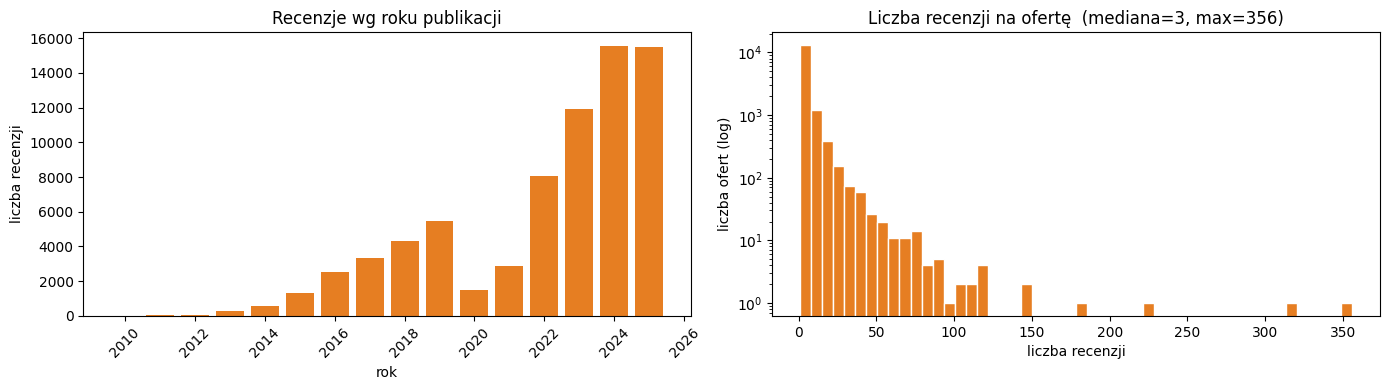

Recenzji z poprawnym listing_id: 73,429
Unikalnych ofert recenzowanych: 15,037
Mediana / średnia recenzji na ofertę: 3 / 4.9
% ofert z >=5 recenzjami: 29.3%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

r_time = reviews_df.dropna(subset=['date']).copy()
r_time['year'] = r_time['date'].dt.year
yc = r_time['year'].value_counts().sort_index()
ax = axes[0]
ax.bar(yc.index.astype(int), yc.values, color='#e67e22')
ax.set_title('Recenzje wg roku publikacji')
ax.set_xlabel('rok')
ax.set_ylabel('liczba recenzji')
ax.tick_params(axis='x', rotation=45)

rpl = reviews_df.dropna(subset=['listing_id']).groupby('listing_id').size()
ax = axes[1]
ax.hist(rpl, bins=50, color='#e67e22', edgecolor='white')
ax.set_yscale('log')
ax.set_title(f'Liczba recenzji na ofertę  (mediana={rpl.median():.0f}, max={rpl.max()})')
ax.set_xlabel('liczba recenzji')
ax.set_ylabel('liczba ofert (log)')

plt.tight_layout()
plt.show()

print(f"Recenzji z poprawnym listing_id: {len(reviews_df.dropna(subset=['listing_id'])):,}")
print(f"Unikalnych ofert recenzowanych: {rpl.size:,}")
print(f"Mediana / średnia recenzji na ofertę: {rpl.median():.0f} / {rpl.mean():.1f}")
print(f"% ofert z >=5 recenzjami: {(rpl >= 5).mean()*100:.1f}%")

Overlap z tabelą Listings (snapshot):
  Unikalnych ofert w sesjach:      17,322
  Unikalnych ofert w Listings:      3,646
  Część wspólna:                    3,646

  % wszystkich sesji dot. ofert z Listings:        68.8%
  % view_listing dot. ofert z Listings:            73.6%
  % recenzji dot. ofert z Listings:                15.1%
  Unikalnych ofert recenzowanych w Listings:        2,353 / 3,646


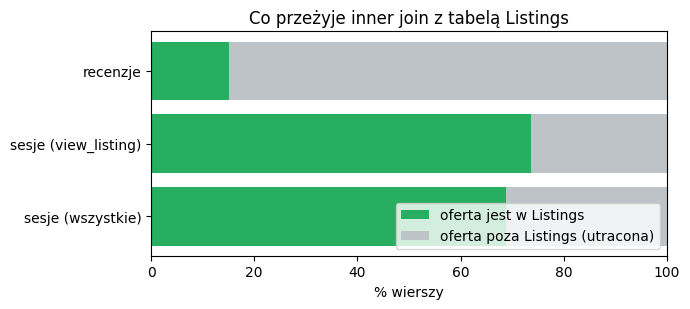

In [ ]:
listings_ids = set(listings_df['id'].dropna().astype('Int64').unique())

sess_clean = sessions_df.dropna(subset=['listing_id'])
sess_in_listings = sess_clean['listing_id'].astype('Int64').isin(listings_ids)
view_clean = sess_clean[sess_clean['action'] == 'view_listing']
view_in_listings = view_clean['listing_id'].astype('Int64').isin(listings_ids)

rev_clean = reviews_df.dropna(subset=['listing_id'])
rev_in_listings = rev_clean['listing_id'].astype('Int64').isin(listings_ids)

print("Overlap z tabelą Listings (snapshot):")
print(f"  Unikalnych ofert w sesjach:     {sess_clean['listing_id'].nunique():>7,}")
print(f"  Unikalnych ofert w Listings:    {len(listings_ids):>7,}")
print(
    f"  Część wspólna:                  {len(set(sess_clean['listing_id'].astype('Int64').unique()) & listings_ids):>7,}")
print()
print(f"  % wszystkich sesji dot. ofert z Listings:       {sess_in_listings.mean()*100:5.1f}%")
print(f"  % view_listing dot. ofert z Listings:           {view_in_listings.mean()*100:5.1f}%")
print(f"  % recenzji dot. ofert z Listings:               {rev_in_listings.mean()*100:5.1f}%")
print(
    f"  Unikalnych ofert recenzowanych w Listings:      {rev_clean[rev_in_listings]['listing_id'].nunique():>7,} / {len(listings_ids):,}")

fig, ax = plt.subplots(1, 1, figsize=(7, 3.2))
labels = ['sesje (wszystkie)', 'sesje (view_listing)', 'recenzje']
in_pct = [sess_in_listings.mean()*100, view_in_listings.mean()*100, rev_in_listings.mean()*100]
out_pct = [100-p for p in in_pct]
ax.barh(labels, in_pct, color='#27ae60', label='oferta jest w Listings')
ax.barh(labels, out_pct, left=in_pct, color='#bdc3c7', label='oferta poza Listings (utracona)')
ax.set_xlim(0, 100)
ax.set_xlabel('% wierszy')
ax.legend(loc='lower right')
ax.set_title('Co przeżyje inner join z tabelą Listings')
plt.tight_layout()
plt.show()

Recenzje i pokrycie tabel:

- Mediana to 3 recenzje na ofertę, więc dla wielu ofert informacji tekstowej jest mało.
- W sesjach jest znacznie więcej unikalnych ofert niż w `Listings`. `Listings` wygląda na snapshot aktualnych ofert.
- Po połączeniu z `Listings` zostaje ok. 74% zdarzeń `view_listing`, ale tylko ok. 12% recenzji dotyczy ofert z `Listings`.
- To ogranicza ile informacji z recenzji faktycznie trafi do modelu.


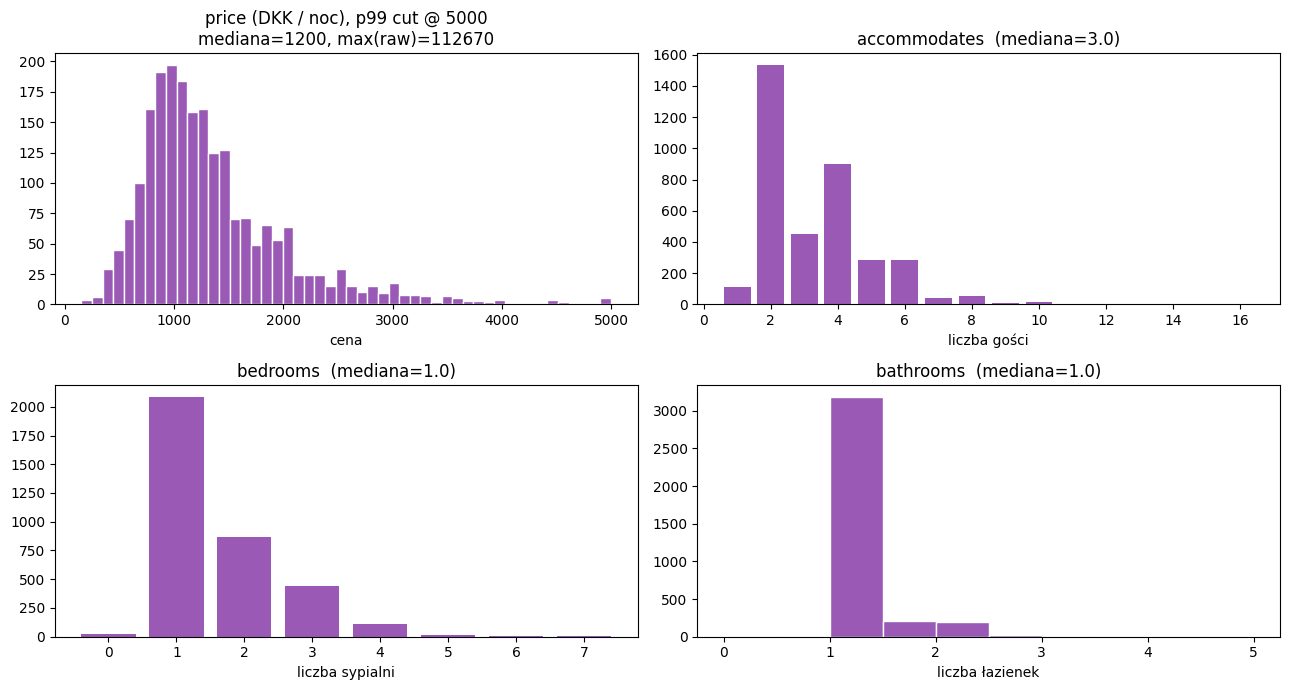

Outliery cenowe: max(raw) = 112670, p99 = 5000, p99.9 = 20550
Liczba ofert z ceną > 10k: 6  (0.27%)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# Price
price = listings_df['price'].dropna()
p99 = price.quantile(0.99)
ax = axes[0, 0]
ax.hist(price[price <= p99].to_numpy(), bins=50, color='#9b59b6', edgecolor='white')
ax.set_title(f'price (DKK / noc), p99 cut @ {p99:.0f}\nmediana={price.median():.0f}, max(raw)={price.max():.0f}')
ax.set_xlabel('cena')

# Accommodates
ax = axes[0, 1]
ac = listings_df['accommodates'].dropna().astype(int).value_counts().sort_index()
ax.bar(np.asarray(ac.index, dtype=int), ac.values, color='#9b59b6')
ax.set_title(f'accommodates  (mediana={listings_df["accommodates"].median()})')
ax.set_xlabel('liczba gości')

# Bedrooms
ax = axes[1, 0]
bd = listings_df['bedrooms'].dropna().astype(int).value_counts().sort_index()
ax.bar(np.asarray(bd.index, dtype=int), bd.values, color='#9b59b6')
ax.set_title(f'bedrooms  (mediana={listings_df["bedrooms"].median()})')
ax.set_xlabel('liczba sypialni')

# Bathrooms
ax = axes[1, 1]
ba = listings_df['bathrooms'].dropna().to_numpy()
ax.hist(ba, bins=int(ba.max())*2 if ba.max() > 0 else 10, color='#9b59b6', edgecolor='white')
ax.set_title(f'bathrooms  (mediana={listings_df["bathrooms"].median()})')
ax.set_xlabel('liczba łazienek')

plt.tight_layout()
plt.show()

print(f"Outliery cenowe: max(raw) = {price.max():.0f}, p99 = {p99:.0f}, p99.9 = {price.quantile(0.999):.0f}")
print(f"Liczba ofert z ceną > 10k: {(price > 10000).sum()}  ({(price > 10000).mean()*100:.2f}%)")

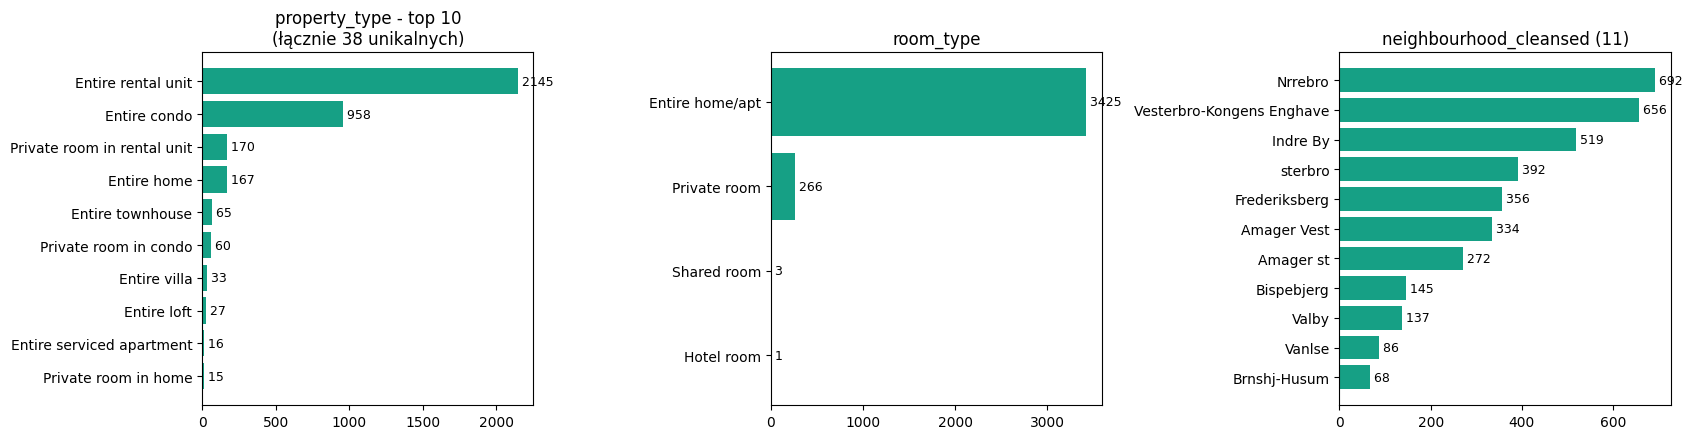

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# property_type  surowy rozkład (przed grupowaniem rzadkich do Other
pt = listings_df['property_type'].dropna().value_counts()
ax = axes[0]
top = pt.head(10)
ax.barh([str(x) for x in top.index[::-1]], top.values[::-1], color='#16a085')
ax.set_title(f'property_type - top 10\n(łącznie {pt.size} unikalnych)')
for i, v in enumerate(top.values[::-1]):
    ax.text(v, i, f' {v}', va='center', fontsize=9)

# room_type
rt = listings_df['room_type'].dropna().value_counts()
ax = axes[1]
ax.barh([str(x) for x in rt.index[::-1]], rt.values[::-1], color='#16a085')
ax.set_title('room_type')
for i, v in enumerate(rt.values[::-1]):
    ax.text(v, i, f' {v}', va='center', fontsize=9)

# neighbourhood
nb = listings_df['neighbourhood_cleansed'].dropna().value_counts()
ax = axes[2]
ax.barh([str(x) for x in nb.index[::-1]], nb.values[::-1], color='#16a085')
ax.set_title(f'neighbourhood_cleansed ({nb.size})')
for i, v in enumerate(nb.values[::-1]):
    ax.text(v, i, f' {v}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Statyczne cechy ofert:

- Cena ma długi ogon i pojedyncze bardzo wysokie wartości.
- Większość ofert to całe mieszkania/domki, a `property_type` ma kilka częstych kategorii i dużo rzadkich.


## Braki danych

Jeśli braku nie da się sensownie zaimputować to usuwamy wiersz.


### Sesje (`sessions.csv`)

Z `sessions` używamy `action`, `user_id`, `timestamp`, `listing_id`. Pozostałe kolumny (`booking_date`, `booking_duration`, `booking_id`) dotyczą zarezerwowanych pobytów i nie wchodzą do modelu konwersji.


Zliczamy braki w kolumnach potrzebnych do odtworzenia ścieżki użytkownika.


In [ ]:
print(f"Null action: {sessions_df['action'].isnull().sum()}")
print(f"Null timestamp: {sessions_df['timestamp'].isnull().sum()}")
print(f'Null user_id: {sessions_df["user_id"].isnull().sum()}')

print()

print(
    f'Null listing in view listing: {((sessions_df["listing_id"].isnull()) & (sessions_df["action"] == "view_listing")).sum()}')
print(
    f'Null listing in book listing: {((sessions_df["listing_id"].isnull()) & (sessions_df["action"] == "book_listing")).sum()}')
print(
    f"Valid listing in book listing: {((sessions_df['action'] == 'book_listing') & (~sessions_df['listing_id'].isnull())).sum()}")

print()

print(f'Null user_id and timestamp: {(sessions_df["timestamp"].isnull() & sessions_df["user_id"].isnull()).sum()}')
print(
    f'Null timestamp and listing id: {(sessions_df["timestamp"].isnull() & sessions_df["listing_id"].isnull()).sum()}')
print(f'Null user_id and listing_id: {(sessions_df["listing_id"].isnull() & sessions_df["user_id"].isnull()).sum()}')

Null action: 247910
Null timestamp: 248636
Null user_id: 247812

Null listing in view listing: 168070
Null listing in book listing: 14828
Valid listing in book listing: 58702

Null user_id and timestamp: 49737
Null timestamp and listing id: 64543
Null user_id and listing_id: 63849


Braków jest dużo. Usuwamy wiersze bez `timestamp`, `user_id`, `action` albo `listing_id`, bo bez nich nie da się przypisać rezerwacji do konkretnego obejrzenia oferty.


In [23]:
sessions_df_clean = sessions_df.dropna(subset=['timestamp', 'user_id', 'listing_id', 'action']).copy()

### Recenzje (`reviews.csv`)


In [24]:
print(f"Null listing: {reviews_df['listing_id'].isnull().sum()}")
print(f"Null date: {reviews_df['date'].isnull().sum()}")
print(f'Null comment: {reviews_df["comments"].isnull().sum()}')

Null listing: 18231
Null date: 18385
Null comment: 18500


Braki są w `listing_id` (~18k), `date` (~18k) i `comments` (~19k). Każda z tych kolumn jest niezbędna: bez nich recenzji nie da się ani przypisać do oferty, ani umiejscowić w czasie, ani przeanalizować sentymentu.


In [25]:
reviews_df_clean = reviews_df.dropna(subset=['listing_id', 'date', 'comments']).copy()

### Listings (`listings.csv`)

Zostajemy z `listing_id`, `property_type`, `room_type`, `accommodates`, `bathrooms`, `bedrooms`, `price`, `neighbourhood_cleansed`. Reszta atrybutów (URL, opis hosta, polityka rezygnacji) jest dla tego zadania mniej przydatna i jedynie podbije liczność cech.


In [26]:
print("Missing values in selected listing columns:")
print(listing_df.isnull().sum())
print(f"\nTotal listings: {len(listing_df)}")

Missing values in selected listing columns:
listing_id                 952
property_type              884
room_type                  903
accommodates               904
bathrooms                  965
bedrooms                  1048
price                     2400
neighbourhood_cleansed     941
dtype: int64

Total listings: 4598


In [27]:
listing_df = listing_df.dropna(subset=['listing_id']).copy()

W `Listings` nie usuwamy wierszy przez braki w cenie, sypialniach czy łazienkach. Te wartości uzupełnimy medianą w kolejnym notatniku, żeby nie tracić całych ofert.


## Analiza sentymentu VADER

Z komentarzy liczymy prosty sentyment: globalny wynik oraz kilka aspektów (czystość, lokalizacja, komunikacja itd.).

To jest przybliżenie. VADER działa najlepiej dla angielskiego, a w danych są też opinie w innych językach. Dla takich komentarzy wynik może być nieprzydatny.


In [28]:
to_estimate_metrics = [
    "review_scores_value", "review_scores_location", "review_scores_communication", "review_scores_checkin", "review_scores_cleanliness",
    "review_scores_accuracy", "review_scores_rating"
]
to_calculate_metrics = ["number_of_reviews", "days_from_last_review"]

In [ ]:
import pandas as pd
import numpy as np
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

aspect_keywords = {
    'review_scores_cleanliness': [
        'clean', 'dirty', 'spotless', 'filthy', 'dust', 'smell', 'tidy', 'stains', 'mess', 'hygiene', 'bathroom'
    ],
    'review_scores_location': [
        'location', 'walk', 'close', 'far', 'subway', 'neighborhood', 'neighbourhood', 'central', 'quiet', 'transport', 'station', 'area', 'bus', 'train', 'city'
    ],
    'review_scores_communication': [
        'host', 'responsive', 'helpful', 'replied', 'communication', 'answering', 'contact', 'message', 'owner'
    ],
    'review_scores_checkin': [
        'check-in', 'check in', 'keys', 'instructions', 'arrival', 'accessible', 'code', 'entering', 'welcome'
    ],
    'review_scores_value': [
        'value', 'price', 'worth', 'cheap', 'expensive', 'money', 'cost', 'deal', 'budget', 'kitchen', 'equipped'
    ],
    'review_scores_accuracy': [
        'accurate', 'description', 'pictures', 'photos', 'expected', 'reality', 'exactly', 'match', 'everything'
    ]
}


def get_aspect_scores(text):
    default_scores = {aspect: 0.0 for aspect in aspect_keywords}
    default_scores['review_scores_rating'] = 0.0

    if pd.isna(text):
        return default_scores

    text_str = str(text).lower()

    global_sentiment = analyzer.polarity_scores(text_str)['compound']

    sentences = re.split(r'[.!?]+', text_str)
    scores = {aspect: [] for aspect in aspect_keywords}

    for sentence in sentences:
        if not sentence.strip():
            continue

        for aspect, keywords in aspect_keywords.items():  # sprawdza czy w komentarzu jest wzmianka o danym aspekcie
            if any(keyword in sentence for keyword in keywords):
                sentiment = analyzer.polarity_scores(sentence)['compound']
                scores[aspect].append(sentiment)

    final_scores = {aspect: (np.mean(vals) if vals else 0.0) for aspect, vals in scores.items()}

    final_scores['review_scores_rating'] = global_sentiment

    return final_scores


print("Calculating full aspect & global sentiments...")
aspect_results = reviews_df_clean['comments'].apply(get_aspect_scores).apply(pd.Series)

reviews_df_scored = pd.concat([reviews_df_clean, aspect_results], axis=1)

print("Ready. Dataframe with VADER scores:")
display(reviews_df_scored.head())

Calculating full aspect & global sentiments...
Ready. Dataframe with VADER scores:


,listing_id,date,comments,review_scores_cleanliness,review_scores_location,review_scores_communication,review_scores_checkin,review_scores_value,review_scores_accuracy,review_scores_rating
1,18920012,2024-04-01,A great location for our first visit to Copenh...,0.0000,0.6249,0.0000,0.4391,0.0000,0.5859,0.8884
2,13096414,2017-07-04,Rune was awesome! The place was in a good loca...,0.0000,0.5485,0.0000,0.0000,0.0000,0.0000,0.9428
3,734446232908975360,2023-01-29,Line was great for checking in and checking ou...,0.9762,0.7218,0.9762,0.0000,0.8969,0.0000,0.9845
5,6428857,2016-02-15,The apartment was easy to find and it was very...,0.0000,0.0000,0.0000,0.0000,0.0000,0.4404,0.8928
7,33286438,2025-06-22,"Prima locatie, prima ruimtes. Leuke wijk, en g...",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


### Rozkłady ocen sentymentu

Sprawdzamy, ile wyników VADER jest zerowych. Dużo zer może oznaczać brak danego aspektu w komentarzu, ale też problem z językiem opinii.


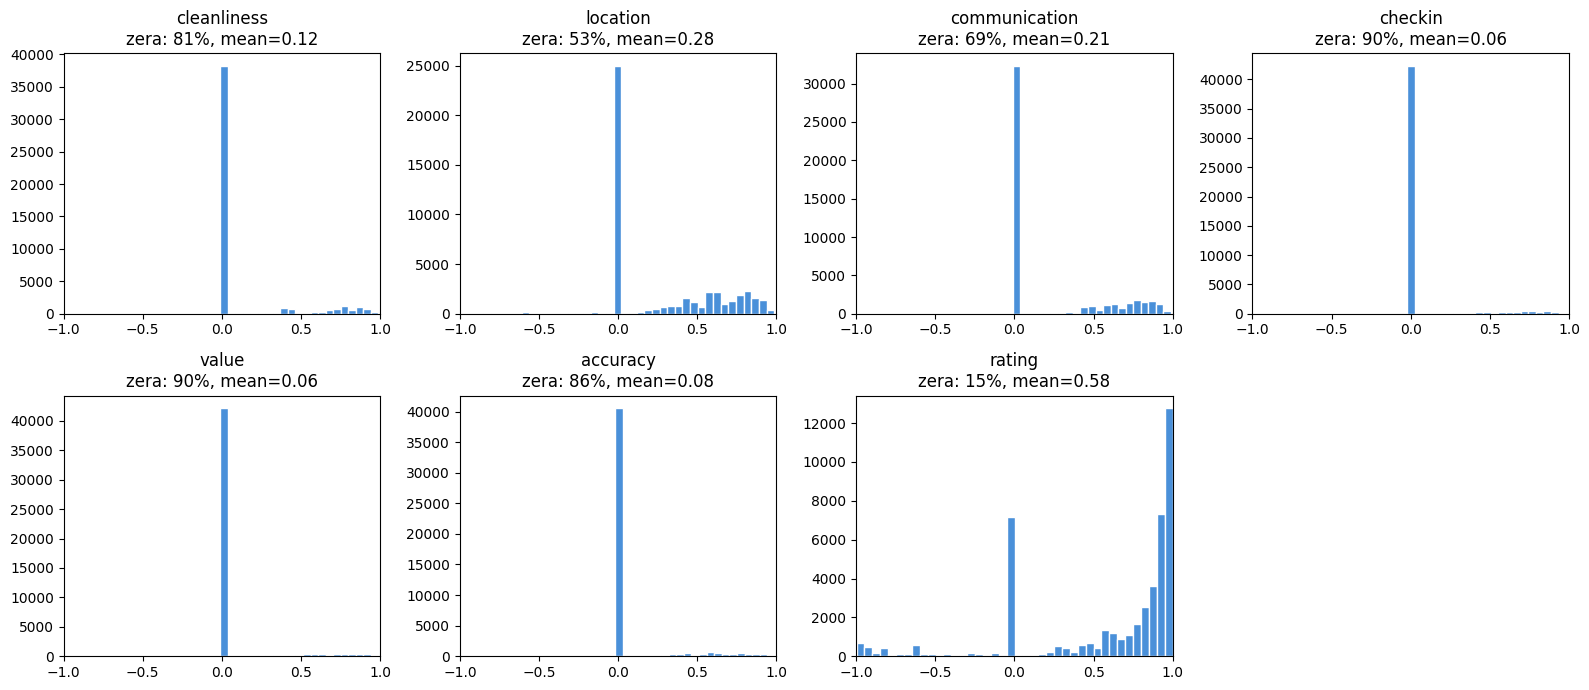

Udziały zer / dodatnich / ujemnych:
  review_scores_cleanliness            =0:  81.5%   >0:  17.8%   <0:   0.7%   mean=+0.116
  review_scores_location               =0:  53.1%   >0:  45.3%   <0:   1.5%   mean=+0.276
  review_scores_communication          =0:  68.9%   >0:  30.7%   <0:   0.4%   mean=+0.211
  review_scores_checkin                =0:  90.2%   >0:   9.1%   <0:   0.7%   mean=+0.056
  review_scores_value                  =0:  89.8%   >0:   9.7%   <0:   0.5%   mean=+0.058
  review_scores_accuracy               =0:  86.4%   >0:  13.2%   <0:   0.4%   mean=+0.078
  review_scores_rating                 =0:  15.2%   >0:  76.4%   <0:   8.4%   mean=+0.582


In [ ]:
import matplotlib.pyplot as plt

sentiment_cols = [c for c in reviews_df_scored.columns if c.startswith('review_scores_')]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(sentiment_cols):
    ax = axes[i]
    vals = reviews_df_scored[col]
    ax.hist(vals, bins=40, color='#4a90d9', edgecolor='white')
    ax.set_title(f"{col.replace('review_scores_', '')}\nzera: {(vals == 0).mean()*100:.0f}%, mean={vals.mean():.2f}")
    ax.set_xlim(-1, 1)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

print("Udziały zer / dodatnich / ujemnych:")
for col in sentiment_cols:
    v = reviews_df_scored[col]
    print(f"  {col:35s}  =0: {(v == 0).mean()*100:5.1f}%   >0: {(v > 0).mean()*100:5.1f}%   <0: {(v < 0).mean()*100:5.1f}%   mean={v.mean():+.3f}")

Wnioski:

- Globalny `rating` ma najwięcej niezerowych wartości.
- Oceny aspektowe mają dużo zer, szczególnie `checkin`, `value` i `accuracy`.
- Część zer to brak wzmianki o danym aspekcie, ale część może wynikać z nieangielskich opinii.


In [31]:
reviews_df_scored.iloc[5]["comments"]

'A cosy apartment with almost everything you need, esp well equipped kitchen. Very nice and quite neighbourhood.'

In [32]:
reviews_df_scored.iloc[5]

listing_id                                                              10595718
date                                                         2017-01-24 00:00:00
comments                       A cosy apartment with almost everything you ne...
review_scores_cleanliness                                                    0.0
review_scores_location                                                    0.4754
review_scores_communication                                                  0.0
review_scores_checkin                                                        0.0
review_scores_value                                                       0.2732
review_scores_accuracy                                                    0.2732
review_scores_rating                                                      0.6361
Name: 9, dtype: object

## Zapis wyników

Surowy tekst komentarzy nie jest dalej potrzebny. Trzymamy oczyszczone wersje tabel z dołączonymi kolumnami sentymentów.


In [ ]:
reviews_df_scored = reviews_df_scored.drop(columns=['comments'])  # sentiment scores are the downstream representation

print("=== Reviews dtypes ===")
print(reviews_df_scored.dtypes)
print("\n=== Sessions dtypes ===")
print(sessions_df_clean.dtypes)
print("\n=== Listings dtypes ===")
print(listing_df.dtypes)

reviews_df_scored.to_csv("../data/interim/reviews_processed.csv", index=False)
sessions_df_clean.to_csv("../data/interim/sessions_processed.csv", index=False)
listing_df.to_csv("../data/interim/listings_processed.csv", index=False)

=== Reviews dtypes ===
listing_id                              Int64
date                           datetime64[us]
review_scores_cleanliness             float64
review_scores_location                float64
review_scores_communication           float64
review_scores_checkin                 float64
review_scores_value                   float64
review_scores_accuracy                float64
review_scores_rating                  float64
dtype: object

=== Sessions dtypes ===
action                   str
user_id                Int64
timestamp     datetime64[us]
listing_id             Int64
dtype: object

=== Listings dtypes ===
listing_id                  Int64
property_type                 str
room_type                     str
accommodates                Int64
bathrooms                 float64
bedrooms                    Int64
price                     float64
neighbourhood_cleansed        str
dtype: object


## Wnioski

- Po wyczyszczeniu danych problem będzie mocno niezbalansowany (mało która sesja kończy się rezerwacją), więc accuracy nie będzie dobrą metryką.
- `Listings` zawiera aktualne oferty przez to część sesji i większość recenzji nie połączy się z pełnymi danymi o ofercie.
- Recenzji na ofertę jest raczej mało, więc cechy świeżych opinii będą dostępne tylko dla części obserwacji.
- VADER nie daje póki co aż tak wiele informaji, zapewne dlatego, że w danych są nieangielskie komentarze. Należy rozważyć użycie serwisu, który tłumaczyłby opinie.
- W kolejnym notatniku sprawdzamy, czy mimo tych ograniczeń cechy recenzji różnią się między rezerwacjami i brakiem rezerwacji.
